    Name: Sienna Joya Haag
    Username: sjhaag
    Student number: S6214320
    Group (AS1, etc.): AS1


In [9]:
# 5.2
import numpy as np
x = np.array
y = np.array
f = open("tentwo", 'r')
x, y = np.loadtxt(f"tentwo", unpack = True)
print(f"The min of x is: {np.min(x)}")
print(f"The max of x is: {np.max(x)}")
print(f"The mean of x is: {np.mean(x)}")
print(f"The min of y is: {np.min(y)}")
print(f"The max of y is: {np.max(y)}")
print(f"The mean of y is: {np.mean(y)}")
y2 = (y - np.median(y))**2
print(y2)

The min of x is: 2.0
The max of x is: 63.0
The mean of x is: 22.9
The min of y is: 2.0
The max of y is: 26.0
The mean of y is: 10.8
[324.  36.  36.   9.   4.  16.   4.  25.  16. 324.]


In [10]:
# 5.6
import numpy as np
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.concatenate((a, b)))

[1 2 3 4 5 6]


In [12]:
import numpy as np
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print(np.concatenate((a, b)))
print(np.concatenate((a, b), axis=0))
print(np.concatenate((a, b), axis=1))
print(np.concatenate((a, b), axis=None))

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]
[1 2 3 4 5 6 7 8]


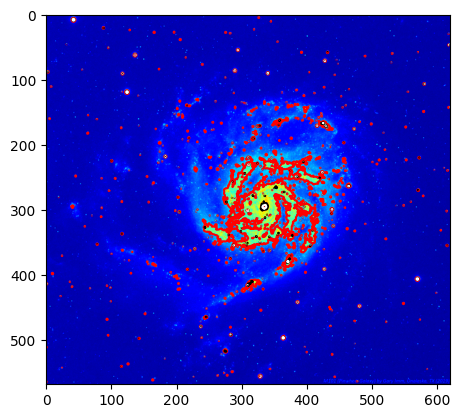

60.0


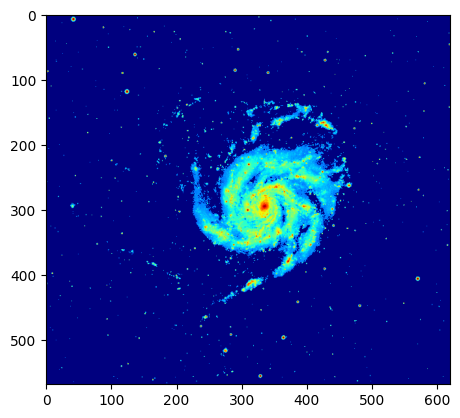

In [39]:
# 5.9
import numpy as np
import imageio.v2 as im
import matplotlib.pyplot as plt

x = im.imread('m101BW.jpg')
plt.imshow(x, cmap='jet') 
plt.contour(x, levels = [100, 200, 225, 250], colors = ['r', 'k', 'w','r'])
plt.show()
print(np.percentile(x, 90))
tenp = np.where(x>60, x, 0)
plt.figure()
a = plt.imshow(tenp, cmap = 'jet')
plt.show()


[0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]
Max = 0.06, min = 0.0, sum = 0.89, mean = 0.02, standard deviation = 0.01


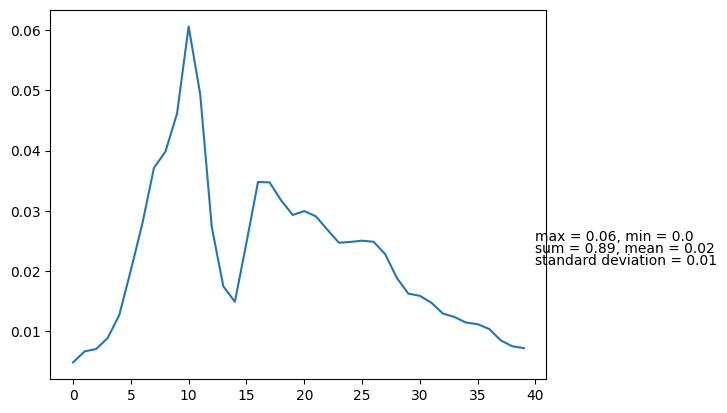

In [131]:
# 5.10
import numpy as np
import matplotlib.pyplot as plt

f = open("NGC6946.txt", 'r')
xyz = np.loadtxt(f, unpack = True)
shape = np.reshape(xyz, [40, 50, 70])
zm = shape[:, 25, 35]
print(zm)
ma, mi,s,mean,std = round(zm.max(),2) , round(zm.min(), 2), round(zm.sum(), 2), round(np.mean(zm), 2), round(np.std(zm), 2)
print(f"Max = {ma}, min = {mi}, sum = {s}, mean = {mean}, standard deviation = {std}")
plt.plot(zm)
plt.text(40, 0.025, f"max = {ma}, min = {mi}")
plt.text(40, 0.023, f"sum = {s}, mean = {mean}")
plt.text(40, 0.021, f"standard deviation = {std}")
plt.show()

/tmp/ipykernel_483999/2294714884.py:10: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  fig.colorbar(a)


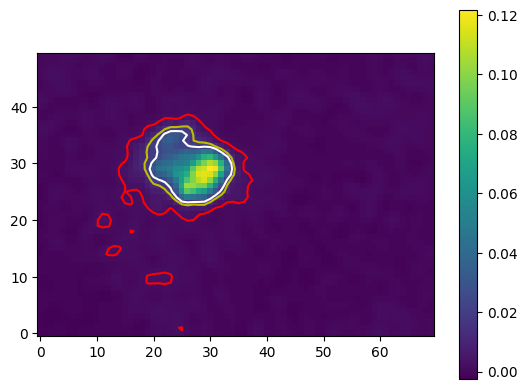

In [133]:
# 5.11
import numpy as np
import matplotlib.pyplot as plt

f = open("NGC6946.txt", 'r')
xyz = np.loadtxt(f, unpack = True)
shape = np.reshape(xyz, [40, 50, 70])
one = shape[0]
a = plt.imshow(one, origin = 'lower')
fig.colorbar(a)
m = one.mean()
st = one.std()
plt.contour(one, levels = [m, m+st, m+std*2], colors = ['r', 'y', 'w'])
plt.show(a)

In [34]:
#5.12

from scipy.constants import c
class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    C = c
    def __init__(self, name, calciumHline=caH_0, lightspeed = C):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        Z = self.redshift()
        V = self.C*Z/1000
        return V
        
gal2 = Galaxy("NGC1832", 3994.7)
vel = gal2.velocity()
print(vel)

1966.2458756852695


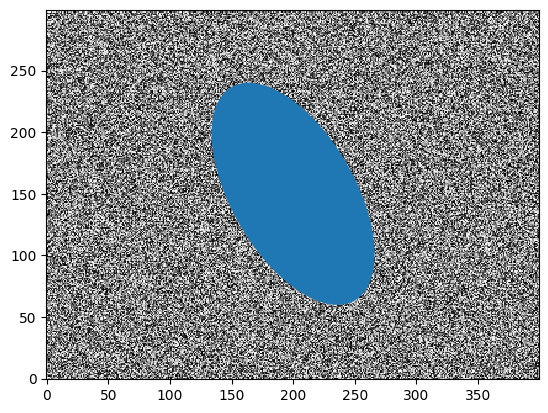

In [35]:
# 5.13
from matplotlib.patches import Ellipse
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))
fig, ax = plt.subplots()
plt.imshow(data, interpolation='none', origin="lower", cmap='gray')

class AstroEllipse(Ellipse):
     def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
ell = AstroEllipse(200, 150, 100, 50, 30)
ax.add_patch(ell)
plt.show()